In [113]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import os
from astropy.constants import c
from astropy import constants as const
import astropy.units as u
from scipy import special


def weight(n):
    return 2 * n**2

def boltzmann(n1, n2, eV, T):
    k = 8.6173303e-5  # Boltzmann constant in eV/K
    g_n = weight(n2) / weight(n1) * np.exp(-eV / (k * T))
    return g_n

def CIV(T):
    sigma_Lya = 5.9e-14 * (T / 1e4) ** (-1/2)
    sigma_CIV = (0.19 / 0.4164) * sigma_Lya * (12) ** (0.5)
    N_CIV_0 = 1 / sigma_CIV
    return sigma_Lya, sigma_CIV, N_CIV_0

sig_ly, sig_c, N_CIV_0 = CIV(1e5)
print("{:.2e}".format(N_CIV_0))

def tau(sig_c, x):
    return sig_c * x

rr = np.arange(13, 18, 1)
ee = [0,1,2,3,4,5,6,7,8,9,10]
em = [1]
atom = [32]
vran_0 = np.arange(200,1000,100)
vran_1 = np.arange(1000,3000,500)
vran = np.append(vran_0,vran_1)
vran = np.append(118,vran)

rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * ee / 10
total_N_c = total_N_c.flatten()

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

C_IV_K_wo = 1548.187 # cm
C_IV_H_wo = 1550.772  # cm

cc = c.to(u.cm / u.s).value
v_th = 11.7673179819719e5  # cm/s

K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952


directory_1 = '~/RT/C_IV/code_tes/data_ran/'

cc_k = c.to(u.km / u.s).value
V_K = 0
V_H = (C_IV_H/C_IV_K -1 ) * cc_k
def function(sigma,lam,lam_k,lam_h):
    tv_k = ((lam-lam_k) / lam_k ) * cc_k
    tv_h = ((lam-lam_h) / lam_h ) * cc_k
    tk = (tv_k)**2 / sigma**2
    th = (tv_h)**2 / sigma**2
    fx = (1 / np.sqrt(2*np.pi*sigma**2))  *(2*np.exp(-tk/2) + np.exp(-th/2) )
    f0 = fx[np.argmax(fx)]
    return fx , f0

# plt.plot(del_V_space_g,yy_g)

3.39e+13


In [26]:
check = 0
for a , index in enumerate(rr):
    for b, expand in enumerate(ee):
        if expand == 10 :
            expand_v = 1
            num_ev = 2 
        elif expand == 0:
            expand_v = 0
            num_ev = 0
        else: 
            num_ev = 1
            expand_v = expand
        for c, vel in enumerate(vran):
            if vel < 1000 :
                 velr_v = vel
                 num_vr = 1
            else:
                velr_v = int(vel/10)
                num_vr = 2
            for d, atom_n in enumerate(atom):
                path_sp_1 = f'{directory_1}N_atom{atom_n}0E+{index}_Vexp{expand_v}00E+0{num_ev}_Vemit100E+00_tauD000E+00_Vran{velr_v}E+0{num_vr}spec_com.dat'         
                try:
                    data_sp_1 = pd.read_csv(path_sp_1, sep='\s+', header=None)
                except FileNotFoundError:
                    print(f"파일을 찾을 수 없습니다: {path_sp_1}")
                    check += 1
                    continue 

                
                sp_dlam_1 = data_sp_1[0].to_numpy()
                globals()[f'Lambda_{atom_n}_{index}_{expand}_{vel}'] =   sp_dlam_1
                sp_1 = data_sp_1[1].to_numpy()

                indices_K_1 = np.where(sp_dlam_1 <= 1550)[0]
                indices_H_1 = np.where(sp_dlam_1 > 1550)[0]

                sp_dlam_K = sp_dlam_1[indices_K_1]
                sp_dlam_H = sp_dlam_1[indices_H_1]

                dlam_k = sp_dlam_K[1]-sp_dlam_K[0]
                dlam_h = sp_dlam_H[1]-sp_dlam_H[0]
                dlam_sp =sp_dlam_1[1] -sp_dlam_1[0]
                # print(dlam_k ,dlam_h,dlam_sp)

                sp_K = sp_1[indices_K_1]
                sp_H = sp_1[indices_H_1]

                if len(sp_K) == 0 or len(sp_H) == 0:
                    print(f"데이터 부족: {path_sp_1}")
                    continue

                del_V_space = (sp_dlam_1 / C_IV_K_wo  - 1) * cc / 1e5  # km/s

                lam_c = (C_IV_H_wo+C_IV_K_wo) / 2
                # print(sep_point)
                indices_K_sp = np.where(sp_dlam_1 <= lam_c )[0]
                indices_H_sp = np.where(sp_dlam_1> lam_c)[0]

                int_Vel_K = del_V_space[indices_K_sp]
                int_Vel_H = del_V_space[indices_H_sp]

                int_flux_K = sp_1[indices_K_sp]
                int_flux_H = sp_1[indices_H_sp]

                delta_lam_K = sp_dlam_1[indices_K_sp]
                delta_lam_H = sp_dlam_1[indices_H_sp]
                globals()[f'delta_lam_K_{atom_n}_{index}_{expand}_{vel}'] = delta_lam_K
                globals()[f'delta_lam_H_{atom_n}_{index}_{expand}_{vel}'] = delta_lam_H  


                globals()[f'I_K_dv_{atom_n}_{index}_{expand}_{vel}'] = int_Vel_K 
                globals()[f'I_K_f_{atom_n}_{index}_{expand}_{vel}'] = int_flux_K

                globals()[f'I_H_dv_{atom_n}_{index}_{expand}_{vel}'] = int_Vel_H  
                globals()[f'I_H_f_{atom_n}_{index}_{expand}_{vel}'] = int_flux_H           
print(check)  

0


In [164]:
def finding_FWHM(x,y,vo):

    y_1 = y[np.where(x <=vo)]
    y_2 = y[np.where(x >vo)]
    x_1 = x[x<=vo]
    x_2 = x[x>vo]
    y_1_max = y_1.max()
    y_2_max = y_2.max()
    yc_1 = y_1.max()/2
    yc_2 = y_2.max()/2  
    x_f_1 = []
    x_f_2 = [] 
    for ii , yy in enumerate(y_1[:-1]):
        bb_1 = (yy - yc_1)*(y_1[ii+1] - yc_1)    
        if bb_1 < 0:
            x_f_1 = np.append(x_f_1,x_1[ii])
    for ii , yy in enumerate(y_2[:-1]):
        bb_2 = (yy - yc_2)*(y_2[ii+1] - yc_2)    
        if bb_2 < 0:
            x_f_2 = np.append(x_f_2,x_2[ii])     

    blue_w = abs(np.min(x_f_1) - x_1[np.argmax(y_1)])
    red_w = abs(np.min(x_f_2) - x_2[np.argmax(y_2)])
    print(np.min(x_f_1))
    return blue_w*2,red_w*2
    

-31.07937833670337
471.86435595599835
--------------------------------------------------
K line  FWHM is  10.20487998966112
H line  FWHM is  10.204879989727715
--------------------------------------------------
-68.97491939899058
436.87342969148693
--------------------------------------------------
K line  FWHM is  26.23835367365499
H line  FWHM is  24.786046274783644
--------------------------------------------------
-109.7944393577682
400.43019602810426
--------------------------------------------------
K line  FWHM is  43.72413475655341
H line  FWHM is  51.02439994850528
--------------------------------------------------
-195.80976557068507
321.7151350071393
--------------------------------------------------
K line  FWHM is  102.04879989691075
H line  FWHM is  154.52550724418745
--------------------------------------------------


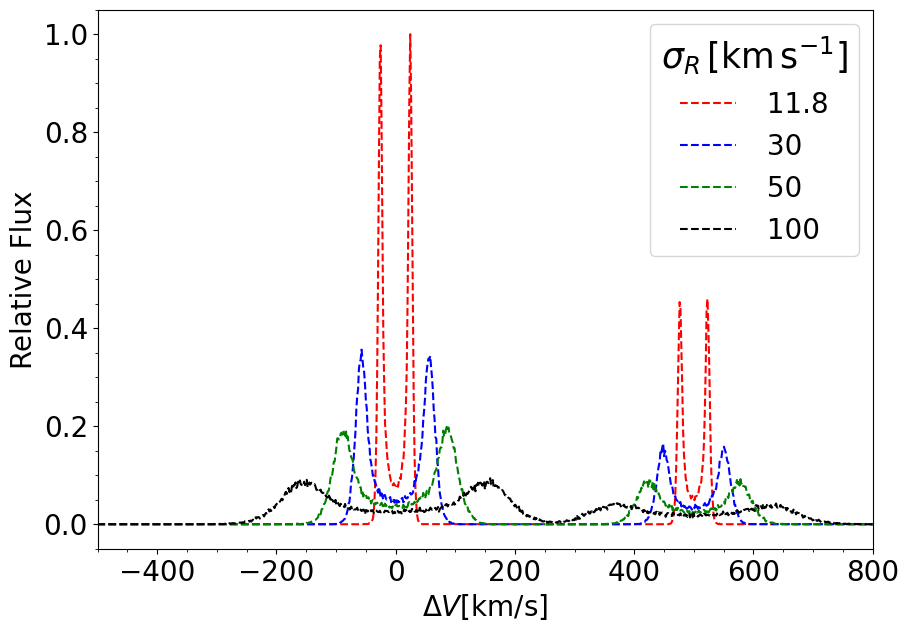

,Random Velocity [km/s],K line FWHM [km/s],H line FWHM [km/s]
0,11.8,10.2,10.2
1,30.0,26.2,24.8
2,50.0,43.7,51.0
3,100.0,102.0,154.5


<Figure size 640x480 with 0 Axes>

In [172]:
fig = plt.figure(1,figsize=(10,7))

atom_n,index, expand = 32,15,0
vel = 118

normal = max(globals()[f'I_K_f_{atom_n}_{index}_{expand}_{vel}'])

plt.plot(globals()[f'I_K_dv_{atom_n}_{index}_{expand}_{vel}'] ,globals()[f'I_K_f_{atom_n}_{index}_{expand}_{vel}']/normal,'r--',label=f' {vel/10}')
plt.plot(globals()[f'I_H_dv_{atom_n}_{index}_{expand}_{vel}'],globals()[f'I_H_f_{atom_n}_{index}_{expand}_{vel}']/normal,'r--')

blue_K, red_K = finding_FWHM(globals()[f'I_K_dv_{atom_n}_{index}_{expand}_{vel}'] ,globals()[f'I_K_f_{atom_n}_{index}_{expand}_{vel}'],V_K)
blue_H, red_H = finding_FWHM(globals()[f'I_H_dv_{atom_n}_{index}_{expand}_{vel}'] ,globals()[f'I_H_f_{atom_n}_{index}_{expand}_{vel}'],V_H)
print('-'*50)
print('K line  FWHM is ', (blue_K +red_K)/2)
print('H line  FWHM is ', (blue_H +red_H)/2)
print('-'*50)
data = {
        'Random Velocity [km/s]': [np.round(vel/10,1)],
        'K line FWHM [km/s]': [np.round((blue_K + red_K) / 2,1)],
        'H line FWHM [km/s]': [np.round((blue_H + red_H) / 2,1)]
    }
df = pd.DataFrame(data)

vel = 300
# normal = max(globals()[f'I_K_f_{atom_n}_{index}_{expand}_{vel}'])
plt.plot(globals()[f'I_K_dv_{atom_n}_{index}_{expand}_{vel}'] ,globals()[f'I_K_f_{atom_n}_{index}_{expand}_{vel}']/normal,'b--',label=f' {int(vel/10)}')
plt.plot(globals()[f'I_H_dv_{atom_n}_{index}_{expand}_{vel}'],globals()[f'I_H_f_{atom_n}_{index}_{expand}_{vel}']/normal,'b--')

blue_K, red_K = finding_FWHM(globals()[f'I_K_dv_{atom_n}_{index}_{expand}_{vel}'] ,globals()[f'I_K_f_{atom_n}_{index}_{expand}_{vel}'],V_K)
blue_H, red_H = finding_FWHM(globals()[f'I_H_dv_{atom_n}_{index}_{expand}_{vel}'] ,globals()[f'I_H_f_{atom_n}_{index}_{expand}_{vel}'],V_H)
print('-'*50)
print('K line  FWHM is ', (blue_K +red_K)/2)
print('H line  FWHM is ', (blue_H +red_H)/2)
print('-'*50)
data = {
        'Random Velocity [km/s]': [np.round(vel/10,1)],
        'K line FWHM [km/s]': [np.round((blue_K + red_K) / 2,1)],
        'H line FWHM [km/s]': [np.round((blue_H + red_H) / 2,1)]
    }
new_df = pd.DataFrame(data)
df = pd.concat([df, new_df], ignore_index=True)
vel = 500
# normal = max(globals()[f'I_K_f_{atom_n}_{index}_{expand}_{vel}'])
plt.plot(globals()[f'I_K_dv_{atom_n}_{index}_{expand}_{vel}'] ,globals()[f'I_K_f_{atom_n}_{index}_{expand}_{vel}']/normal,'g--',label=f' {int(vel/10)}')
plt.plot(globals()[f'I_H_dv_{atom_n}_{index}_{expand}_{vel}'],globals()[f'I_H_f_{atom_n}_{index}_{expand}_{vel}']/normal,'g--')
blue_K, red_K = finding_FWHM(globals()[f'I_K_dv_{atom_n}_{index}_{expand}_{vel}'] ,globals()[f'I_K_f_{atom_n}_{index}_{expand}_{vel}'],V_K)
blue_H, red_H = finding_FWHM(globals()[f'I_H_dv_{atom_n}_{index}_{expand}_{vel}'] ,globals()[f'I_H_f_{atom_n}_{index}_{expand}_{vel}'],V_H)
print('-'*50)
print('K line  FWHM is ', (blue_K +red_K)/2)
print('H line  FWHM is ', (blue_H +red_H)/2)
print('-'*50)

data = {
        'Random Velocity [km/s]': [np.round(vel/10,1)],
        'K line FWHM [km/s]': [np.round((blue_K + red_K) / 2,1)],
        'H line FWHM [km/s]': [np.round((blue_H + red_H) / 2,1)]
    }
new_df = pd.DataFrame(data)
df = pd.concat([df, new_df], ignore_index=True)

vel = 1000
# normal = max(globals()[f'I_K_f_{atom_n}_{index}_{expand}_{vel}'])
plt.plot(globals()[f'I_K_dv_{atom_n}_{index}_{expand}_{vel}'] ,globals()[f'I_K_f_{atom_n}_{index}_{expand}_{vel}']/normal,'k--',label=f' {int(vel/10)}')
plt.plot(globals()[f'I_H_dv_{atom_n}_{index}_{expand}_{vel}'],globals()[f'I_H_f_{atom_n}_{index}_{expand}_{vel}']/normal,'k--')
blue_K, red_K = finding_FWHM(globals()[f'I_K_dv_{atom_n}_{index}_{expand}_{vel}'] ,globals()[f'I_K_f_{atom_n}_{index}_{expand}_{vel}'],V_K)
blue_H, red_H = finding_FWHM(globals()[f'I_H_dv_{atom_n}_{index}_{expand}_{vel}'] ,globals()[f'I_H_f_{atom_n}_{index}_{expand}_{vel}'],V_H)
print('-'*50)
print('K line  FWHM is ', (blue_K +red_K)/2)
print('H line  FWHM is ', (blue_H +red_H)/2)
print('-'*50)
data = {
        'Random Velocity [km/s]': [np.round(vel/10,1)],
        'K line FWHM [km/s]': [np.round((blue_K + red_K) / 2,1)],
        'H line FWHM [km/s]': [np.round((blue_H + red_H) / 2,1)]
    }
new_df = pd.DataFrame(data)
df = pd.concat([df, new_df], ignore_index=True)

plt.xlabel(r'$\Delta V [\rm km/s]$', fontsize= 20)
plt.ylabel('Relative Flux',fontsize=20)
plt.minorticks_on()
plt.xlim(-500,800)
plt.legend(title=r'$\sigma_R \, [\rm km \, s^{-1}]$', fontsize=20, title_fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()
plt.savefig(r'/home/jin/바탕화면/various_random_Velocity.pdf',bbox_inches='tight')
df
